In [ ]:
"""
SHEIN E-commerce Cleaning Project

Plan(after loading, merging and initial audit):
Phase 1: Remove duplicates
Phase 2: Clean price column
Phase 3: Normalize categories/titles
Phase 4: Handle missing values
Phase 5: Feature engineering (final_price, discount impact)
"""

# 01 - LOAD & MERGE DATA

import pandas as pd
import os

path = "../data/Raw/"

files = os.listdir(path)
files

['us-shein-appliances-3987.csv',
 'us-shein-automotive-4110.csv',
 'us-shein-baby_and_maternity-4433.csv',
 'us-shein-bags_and_luggage-4299.csv',
 'us-shein-beauty_and_health-4267.csv',
 'us-shein-curve-2849.csv',
 'us-shein-electronics-4395.csv',
 'us-shein-home_and_kitchen-3719.csv',
 'us-shein-home_textile-3883.csv',
 'us-shein-jewelry_and_accessories-3548.csv',
 'us-shein-kids-4314.csv',
 'us-shein-mens_clothes-1891.csv',
 'us-shein-office_and_school_supplies-4233.csv',
 'us-shein-pet_supplies-4083.csv',
 'us-shein-shoes-4381.csv',
 'us-shein-sports_and_outdoors-3853.csv',
 'us-shein-swimwear-3761.csv',
 'us-shein-tools_and_home_improvement-3903.csv',
 'us-shein-toys_and_games-3577.csv',
 'us-shein-underwear_and_sleepwear-4019.csv',
 'us-shein-womens_clothing-4620.csv']

In [11]:
dfs = []

for file in files:
    df_temp = pd.read_csv(path + file)
    df_temp["source_file"] = file
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

(82105, 13)

In [ ]:
# 02 - DATA AUDIT (SHAPE, NULLS, DUPLICATES)
df.head()

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link,source_file,color-count,blackfridaybelts-bg src,blackfridaybelts-content,product-locatelabels-img src
0,1pc Rechargeable Deep Tissue Muscle Handheld M...,https://us.shein.com/1pc-Rechargeable-Deep-Tis...,#1 Best Sellers,in Give Gifts,$2.03,-22%,NaN,NaN,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
1,1pc Portable Hanging Neck Fan,https://us.shein.com/1pc-Portable-Hanging-Neck...,#4 Best Sellers,in Top rated in Portable Fans,$6.48,-20%,NaN,NaN,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
2,1pc Pink Colored Curved Eyelash Curler False E...,https://us.shein.com/1pc-Pink-Colored-Curved-E...,NaN,NaN,$1.80,NaN,400+ sold recently,NaN,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
3,1 Mini Portable Handheld Fan With 2 Aa Batteri...,https://us.shein.com/1-Mini-Portable-Handheld-...,NaN,NaN,$0.88,-72%,5.6k+ sold recently,NaN,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
4,"Wit Water Flosser,Portable Oral Irrigator With...",https://us.shein.com/Wit-Water-Flosser-Portabl...,#6 Best Sellers,in Oral Irrigators,$12.06,-40%,NaN,NaN,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82105 entries, 0 to 82104
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   goods-title-link--jump        664 non-null    object 
 1   goods-title-link--jump href   664 non-null    object 
 2   rank-title                    14605 non-null  object 
 3   rank-sub                      14605 non-null  object 
 4   price                         82103 non-null  object 
 5   discount                      54977 non-null  object 
 6   selling_proposition           54364 non-null  object 
 7   goods-title-link              81427 non-null  object 
 8   source_file                   82105 non-null  object 
 9   color-count                   19743 non-null  float64
 10  blackfridaybelts-bg src       3791 non-null   object 
 11  blackfridaybelts-content      3791 non-null   object 
 12  product-locatelabels-img src  3622 non-null   object 
dtypes

In [8]:
df.isnull().sum().sort_values(ascending=False)

goods-title-link--jump          81441
goods-title-link--jump href     81441
product-locatelabels-img src    78483
blackfridaybelts-bg src         78314
blackfridaybelts-content        78314
rank-title                      67500
rank-sub                        67500
color-count                     62362
selling_proposition             27741
discount                        27128
goods-title-link                  678
price                               2
source_file                         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2876)

In [12]:
df[df.duplicated(keep=False)].sort_values("goods-title-link")

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link,source_file,color-count,blackfridaybelts-bg src,blackfridaybelts-content,product-locatelabels-img src
56121,NaN,NaN,NaN,NaN,$22.16,-20%,200+ sold recently,(Plus Size) Women's Peep Toe High Heels White ...,us-shein-shoes-4381.csv,5.0,NaN,NaN,NaN
56143,NaN,NaN,NaN,NaN,$22.16,-20%,200+ sold recently,(Plus Size) Women's Peep Toe High Heels White ...,us-shein-shoes-4381.csv,5.0,NaN,NaN,NaN
76558,NaN,NaN,NaN,NaN,$8.99,-5%,1.5k+ sold recently,(random Floral Pattern) Sexy Embroidery Garter...,us-shein-underwear_and_sleepwear-4019.csv,NaN,NaN,NaN,NaN
76586,NaN,NaN,NaN,NaN,$8.99,-5%,1.5k+ sold recently,(random Floral Pattern) Sexy Embroidery Garter...,us-shein-underwear_and_sleepwear-4019.csv,NaN,NaN,NaN,NaN
77603,NaN,NaN,NaN,NaN,$8.00,-1%,50+ sold recently,"1 Beach Towel, 75CM * 150CM, Purple Half Skull...",us-shein-womens_clothing-4620.csv,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41939,NaN,NaN,NaN,NaN,$6.70,-8%,100+ sold recently,"Young Girls' 2-Piece Set, Double-Layer Ruffled...",us-shein-kids-4314.csv,4.0,NaN,NaN,NaN
51321,NaN,NaN,NaN,NaN,$1.09,-22%,200+ sold recently,Zinc Alloy Pet Tag With Laser Engraved Gold Pa...,us-shein-pet_supplies-4083.csv,NaN,NaN,NaN,NaN
51370,NaN,NaN,NaN,NaN,$1.09,-22%,200+ sold recently,Zinc Alloy Pet Tag With Laser Engraved Gold Pa...,us-shein-pet_supplies-4083.csv,NaN,NaN,NaN,NaN
37143,NaN,NaN,NaN,NaN,$2.70,NaN,1.4k+ sold recently,[7PCS] Popular Bohemian Style Colorful Beaded ...,us-shein-jewelry_and_accessories-3548.csv,NaN,NaN,NaN,NaN


In [13]:
df[df.duplicated()].head(20)

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link,source_file,color-count,blackfridaybelts-bg src,blackfridaybelts-content,product-locatelabels-img src
940,NaN,NaN,NaN,NaN,$14.10,NaN,100+ sold recently,Sonic Skin Scrubber Skin Spatula Peeling Machi...,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
993,NaN,NaN,NaN,NaN,$9.90,NaN,200+ sold recently,1PC Rechargeable 2000mAh Portable Hanging Neck...,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
1101,NaN,NaN,NaN,NaN,$5.70,-3%,200+ sold recently,"Pocket Mirror, 1X/2X Magnification LED Compact...",us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
1378,NaN,NaN,NaN,NaN,$7.60,NaN,200+ sold recently,Stay Cool On-The-Go: Small Handheld USB Fan - ...,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
1786,NaN,NaN,NaN,NaN,$9.63,-10%,10+ sold recently,"1pc Rechargeable Fashionable Neck Hanging Fan,...",us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
1815,NaN,NaN,NaN,NaN,$4.80,NaN,1.2k+ sold recently,Stay Cool On-The-Go: 1pc Portable USB Mini Fan,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
2074,NaN,NaN,NaN,NaN,$23.99,-70%,NaN,"Cooling Neck Fan Portable, 2024 New Wearable B...",us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
2089,NaN,NaN,NaN,NaN,$3.05,-50%,NaN,"10-Pack Body Warmer Patch For Hands, Feet, Wai...",us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
2128,NaN,NaN,NaN,NaN,$26.10,NaN,NaN,1pc Mini USB Rechargeable Portable Outdoor Par...,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN
2171,NaN,NaN,NaN,NaN,$11.00,NaN,30+ sold recently,Multi-Functional Simple White Egg Steamer For ...,us-shein-appliances-3987.csv,NaN,NaN,NaN,NaN


In [14]:
#  Freeze raw dataset (safety checkpoint)

df_raw = df.copy()

print("Raw shape:", df_raw.shape)

Raw shape: (82105, 13)


In [15]:
# STEP 3A - Check duplicates

print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 2876


In [17]:
# STEP 3B - Check duplicates based on product title only

df.duplicated(subset=["goods-title-link"]).sum()

np.int64(11104)

In [19]:
# STEP 3C FINAL - Remove product duplicates

df = df.drop_duplicates(subset=["goods-title-link"])

print("Shape after product dedupe:", df.shape)

Shape after product dedupe: (71001, 13)


In [20]:
# STEP 4A - Inspect price column

print(df["price"].head(10))
print("\nMissing prices:", df["price"].isnull().sum())

0      $2.03
40     $2.70
41     $4.38
42     $2.86
43     $3.46
44     $2.40
45     $2.60
46     $2.10
47    $35.00
48     $4.40
Name: price, dtype: object

Missing prices: 0


In [21]:
# STEP 4B - Clean price column

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

print(df["price"].describe())

count     71001.000000
mean         24.299586
std        3336.078318
min           0.150000
25%           2.500000
50%           6.000000
75%          11.600000
max      888888.000000
Name: price, dtype: float64


In [22]:
df["price"].isnull().sum()

np.int64(0)

In [23]:
# STEP 4C - Inspect extreme values

print("Top 20 highest prices:")
print(df["price"].sort_values(ascending=False).head(20))

print("\nBottom 20 lowest prices:")
print(df["price"].sort_values(ascending=True).head(20))

Top 20 highest prices:
32419    888888.00
3401       2399.99
47177      2305.46
2849       2254.99
68891      1998.99
69046      1568.71
1441       1430.99
3973       1399.99
3258       1398.00
69053      1358.99
3415       1299.99
3978       1299.99
28264      1199.00
68824      1176.31
3206       1174.99
1959       1077.99
68825      1045.81
69809      1028.98
68908       970.73
2988        963.72
Name: price, dtype: float64

Bottom 20 lowest prices:
18160    0.15
18559    0.18
67032    0.18
19464    0.18
18575    0.18
20046    0.18
14565    0.22
31776    0.22
29560    0.23
32991    0.23
48750    0.23
66057    0.24
13107    0.24
36061    0.24
68768    0.24
66108    0.25
29175    0.25
36766    0.25
45886    0.26
66037    0.26
Name: price, dtype: float64


In [24]:
# STEP 4C - Percentile check

print(df["price"].quantile([0.01, 0.05, 0.50, 0.95, 0.99]))

0.01      0.75
0.05      1.30
0.50      6.00
0.95     29.99
0.99    123.99
Name: price, dtype: float64


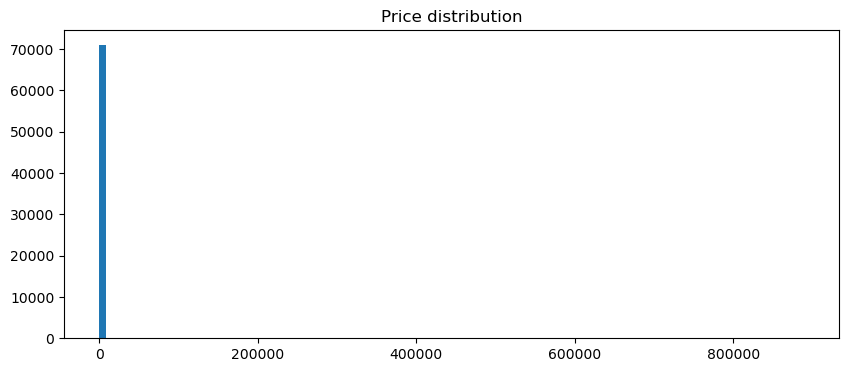

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(df["price"], bins=100)
plt.title("Price distribution")
plt.show()

In [ ]:
# remove extreme impossible values
df = df[df["price"] < 10000]

In [ ]:
 # percentile-based trimming
df = df[df["price"] <= df["price"].quantile(0.99)]

<Axes: >

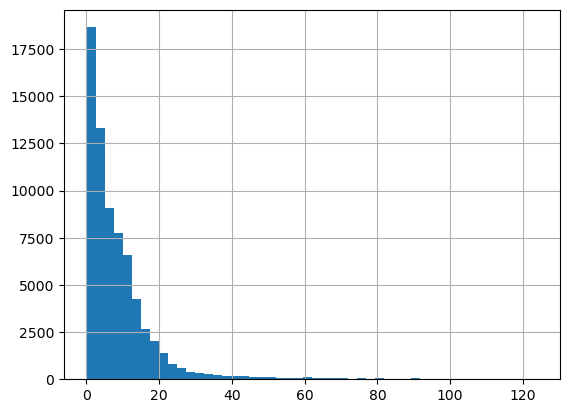

In [28]:
df["price"].hist(bins=50)

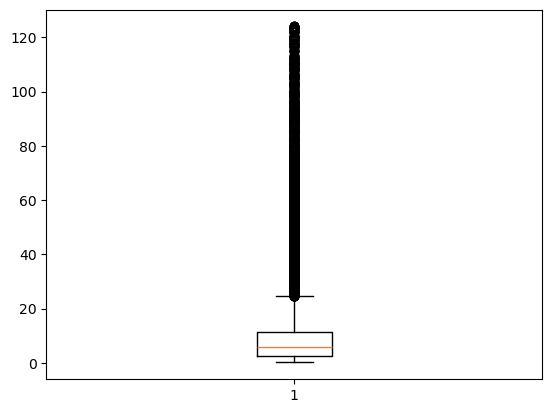

In [29]:
import matplotlib.pyplot as plt

plt.boxplot(df["price"])
plt.show()

In [30]:
df["price"].dtype

dtype('float64')

In [31]:
df["discount"] = (
    df["discount"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("-", "", regex=False)
)

df["discount"] = pd.to_numeric(df["discount"], errors="coerce")

In [32]:
df["discount"].head(10)
df["discount"].dtype
df["discount"].describe()

count    46689.000000
mean        21.810855
std         16.628688
min          1.000000
25%          8.000000
50%         18.000000
75%         30.000000
max         92.000000
Name: discount, dtype: float64

In [33]:
df["discount"].isna().sum()

np.int64(23603)

In [41]:
df["selling_proposition"].value_counts().head(20)

selling_proposition
100+ sold recently     6727
200+ sold recently     4481
300+ sold recently     3334
400+ sold recently     2582
500+ sold recently     2079
10+ sold recently      1896
600+ sold recently     1754
700+ sold recently     1463
800+ sold recently     1338
20+ sold recently      1334
30+ sold recently      1130
40+ sold recently      1076
900+ sold recently     1043
50+ sold recently      1022
60+ sold recently       972
1.0k+ sold recently     955
70+ sold recently       938
80+ sold recently       917
90+ sold recently       830
1.1k+ sold recently     813
Name: count, dtype: int64

In [42]:
df["units_sold_raw"] = (
    df["selling_proposition"]
    .astype(str)
    .str.lower()
    .str.replace("sold recently", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.strip()
)

In [43]:
def convert_sales(x):
    if x in ["nan", "none", "", "null"]:
        return None

    try:
        x = x.strip()

        if "k" in x:
            return float(x.replace("k", "")) * 1000

        return float(x)

    except:
        return None


df["units_sold"] = df["units_sold_raw"].apply(convert_sales)

In [44]:
df[["selling_proposition", "units_sold_raw", "units_sold"]].head(10)
df["units_sold"].describe()

count    47057.000000
mean       947.804152
std       1665.025093
min         10.000000
25%        100.000000
50%        300.000000
75%       1000.000000
max      10000.000000
Name: units_sold, dtype: float64

In [45]:
df.sort_values("units_sold", ascending=False).head(10)

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link,source_file,color-count,blackfridaybelts-bg src,blackfridaybelts-content,product-locatelabels-img src,units_sold,units_sold_raw
80143,NaN,NaN,NaN,NaN,3.32,10.0,10k+ sold recently,SHEIN EZwear Summer Outfit Solid Knit Tube Top,us-shein-womens_clothing-4620.csv,21.0,NaN,NaN,https://img.ltwebstatic.com/images3_pi/2022/11...,10000.0,10k
73988,NaN,NaN,NaN,NaN,9.59,8.0,10k+ sold recently,5pcs Men's Letter Print Underwear With Woven W...,us-shein-underwear_and_sleepwear-4019.csv,NaN,NaN,NaN,NaN,10000.0,10k
37012,NaN,NaN,NaN,NaN,1.80,NaN,10k+ sold recently,1 Set Of Niche Design Cool Style Long Double L...,us-shein-jewelry_and_accessories-3548.csv,NaN,NaN,NaN,NaN,10000.0,10k
78663,NaN,NaN,NaN,NaN,12.44,5.0,10k+ sold recently,SHEIN Slayr Women'S Rainbow & Slogan Print Dre...,us-shein-womens_clothing-4620.csv,NaN,NaN,NaN,https://img.ltwebstatic.com/images3_pi/2023/06...,10000.0,10k
78659,NaN,NaN,NaN,NaN,16.55,15.0,10k+ sold recently,SHEIN ICON Ripped Raw Hem Denim Shorts,us-shein-womens_clothing-4620.csv,NaN,NaN,NaN,https://img.ltwebstatic.com/images3_pi/2022/11...,10000.0,10k
77647,NaN,NaN,NaN,NaN,5.98,5.0,10k+ sold recently,SHEIN EZwear Elastic Waist Striped Shorts,us-shein-womens_clothing-4620.csv,NaN,NaN,NaN,https://img.ltwebstatic.com/images3_pi/2022/11...,10000.0,10k
75729,NaN,NaN,NaN,NaN,4.94,8.0,10k+ sold recently,1pc Women's Front Closure Bra With Steel Ring,us-shein-underwear_and_sleepwear-4019.csv,4.0,NaN,NaN,NaN,10000.0,10k
78655,NaN,NaN,NaN,NaN,8.49,NaN,10k+ sold recently,SHEIN Aloruh Women's Off Shoulder V-Neckline W...,us-shein-womens_clothing-4620.csv,9.0,NaN,NaN,https://img.ltwebstatic.com/images3_pi/2024/02...,10000.0,10k
75753,NaN,NaN,NaN,NaN,3.19,9.0,10k+ sold recently,Women's Strapless Knitted Push Up Bra With Inv...,us-shein-underwear_and_sleepwear-4019.csv,4.0,NaN,NaN,NaN,10000.0,10k
78650,NaN,NaN,NaN,NaN,11.09,NaN,10k+ sold recently,Solid Curved Hem Cami Dress,us-shein-womens_clothing-4620.csv,30.0,NaN,NaN,NaN,10000.0,10k


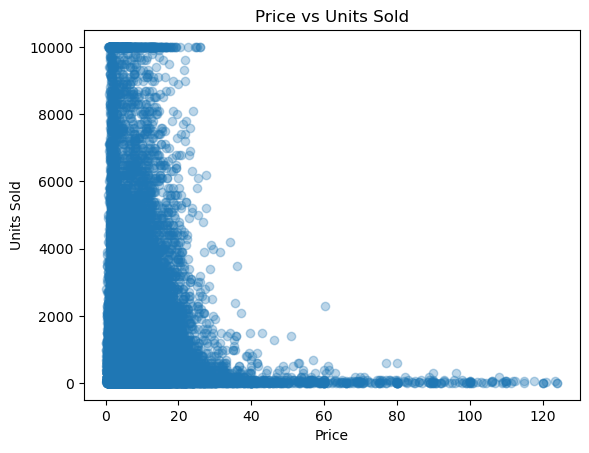

In [46]:
import matplotlib.pyplot as plt

plt.scatter(df["price"], df["units_sold"], alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()

In [47]:
df.groupby("source_file")["units_sold"].mean().sort_values(ascending=False)

source_file
us-shein-womens_clothing-4620.csv               2468.831308
us-shein-jewelry_and_accessories-3548.csv       2284.049803
us-shein-beauty_and_health-4267.csv             1685.066294
us-shein-mens_clothes-1891.csv                  1458.415751
us-shein-curve-2849.csv                         1207.548973
us-shein-underwear_and_sleepwear-4019.csv       1203.544759
us-shein-sports_and_outdoors-3853.csv           1074.085028
us-shein-kids-4314.csv                          1053.315269
us-shein-electronics-4395.csv                   1009.920635
us-shein-shoes-4381.csv                          954.000000
us-shein-home_and_kitchen-3719.csv               784.852130
us-shein-bags_and_luggage-4299.csv               752.325917
us-shein-baby_and_maternity-4433.csv             601.877032
us-shein-automotive-4110.csv                     378.472441
us-shein-tools_and_home_improvement-3903.csv     342.460407
us-shein-office_and_school_supplies-4233.csv     305.236769
us-shein-toys_and_games-3577

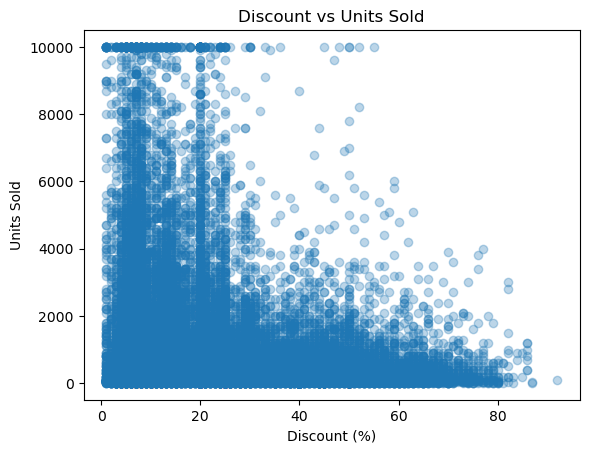

In [48]:
plt.scatter(df["discount"], df["units_sold"], alpha=0.3)
plt.xlabel("Discount (%)")
plt.ylabel("Units Sold")
plt.title("Discount vs Units Sold")
plt.show()

In [49]:
df[["goods-title-link--jump", "price", "units_sold"]].sort_values("units_sold", ascending=False).head(20)

,goods-title-link--jump,price,units_sold
80143,NaN,3.32,10000.0
73988,NaN,9.59,10000.0
37012,NaN,1.80,10000.0
78663,NaN,12.44,10000.0
78659,NaN,16.55,10000.0
77647,NaN,5.98,10000.0
75729,NaN,4.94,10000.0
78655,NaN,8.49,10000.0
75753,NaN,3.19,10000.0
78650,NaN,11.09,10000.0


In [50]:
df["units_sold"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    47057.000000
mean       947.804152
std       1665.025093
min         10.000000
50%        300.000000
90%       2500.000000
95%       4200.000000
99%      10000.000000
max      10000.000000
Name: units_sold, dtype: float64

In [51]:
df[df["units_sold"] > 10000].head()

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link,source_file,color-count,blackfridaybelts-bg src,blackfridaybelts-content,product-locatelabels-img src,units_sold,units_sold_raw


In [52]:
df["units_sold"].value_counts().head(10)

units_sold
100.0    6727
200.0    4481
300.0    3334
400.0    2582
500.0    2079
10.0     1896
600.0    1754
700.0    1463
800.0    1338
20.0     1334
Name: count, dtype: int64

In [53]:
df["units_sold"].value_counts().tail(10)

units_sold
9200.0    15
8900.0    14
8400.0    13
9700.0    13
9500.0    13
7900.0    12
9300.0    10
9900.0     9
9800.0     8
8800.0     7
Name: count, dtype: int64

In [55]:
import numpy as np

In [57]:
df["units_sold_log"] = np.log1p(df["units_sold"])

In [58]:
df[["units_sold", "units_sold_log"]].head()
df["units_sold_log"].describe()

count    47057.000000
mean         5.723857
std          1.597550
min          2.397895
25%          4.615121
50%          5.707110
75%          6.908755
max          9.210440
Name: units_sold_log, dtype: float64

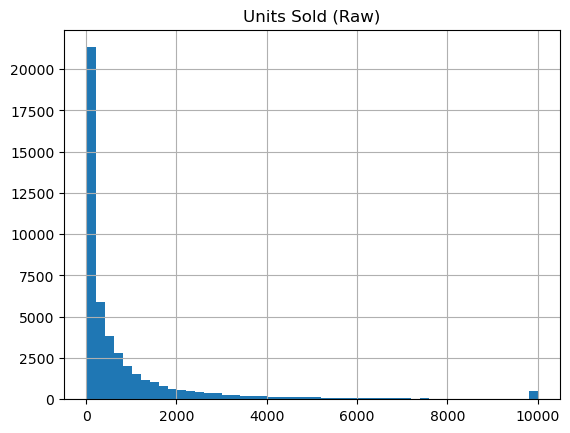

In [59]:

df["units_sold"].hist(bins=50)
plt.title("Units Sold (Raw)")
plt.show()

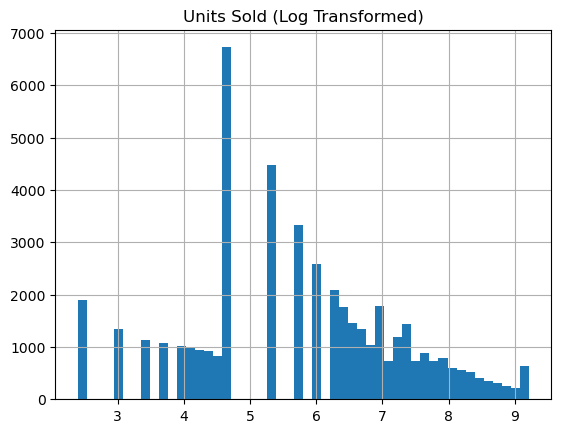

In [60]:
df["units_sold_log"].hist(bins=50)
plt.title("Units Sold (Log Transformed)")
plt.show()

In [61]:
df_feat = df.copy()

In [62]:
df_feat["price"].dtype

dtype('float64')

In [63]:
df_feat["price_category"] = pd.cut(
    df_feat["price"],
    bins=[0, 10, 30, float("inf")],
    labels=["low", "mid", "high"]
)

In [64]:
df_feat["has_discount"] = df_feat["discount"].notna()
df_feat["has_discount"].value_counts()

has_discount
True     46689
False    23603
Name: count, dtype: int64

In [65]:
df_feat["discount"] = (
    df_feat["discount"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("-", "", regex=False)
)

df_feat["discount"] = pd.to_numeric(df_feat["discount"], errors="coerce")

In [66]:
df_feat["discount"].describe()

count    46689.000000
mean        21.810855
std         16.628688
min          1.000000
25%          8.000000
50%         18.000000
75%         30.000000
max         92.000000
Name: discount, dtype: float64

In [67]:
df_feat["discount"].isna().sum()

np.int64(23603)

In [68]:
df_feat["value_score"] = df_feat["units_sold"] / df_feat["price"]

In [69]:
df_feat["value_score"].describe()

count    47057.000000
mean       282.929893
std        712.427927
min          0.080652
25%         17.406440
50%         65.907729
75%        227.488152
max      12987.012987
Name: value_score, dtype: float64

In [70]:
df_feat[["goods-title-link--jump", "price", "units_sold", "value_score"]].sort_values(
    "value_score", ascending=False
).head(10)

,goods-title-link--jump,price,units_sold,value_score
36047,NaN,0.77,10000.0,12987.012987
14565,NaN,0.22,2800.0,12727.272727
73258,NaN,0.33,3900.0,11818.181818
18427,NaN,0.85,10000.0,11764.705882
28348,NaN,0.86,10000.0,11627.906977
36423,NaN,0.88,10000.0,11363.636364
36432,NaN,0.29,3000.0,10344.827586
36823,NaN,1.00,10000.0,10000.000000
37024,NaN,0.57,5600.0,9824.561404
36527,NaN,0.96,9400.0,9791.666667


In [71]:
# 1. Check extreme low-price items
df_feat[df_feat["price"] < 1][["price", "units_sold", "value_score"]].head(10)

,price,units_sold,value_score
81,0.87,40.0,45.977011
129,0.50,NaN,NaN
385,0.90,NaN,NaN
429,0.74,100.0,135.135135
554,0.66,NaN,NaN
909,0.65,100.0,153.846154
1025,0.85,NaN,NaN
1063,0.95,NaN,NaN
1484,0.80,NaN,NaN
1656,0.80,NaN,NaN


In [72]:
# 2. Check correlation sanity
df_feat[["price", "units_sold", "value_score"]].corr()

,price,units_sold,value_score
price,1.000000,-0.042122,-0.195538
units_sold,-0.042122,1.000000,0.711616
value_score,-0.195538,0.711616,1.000000


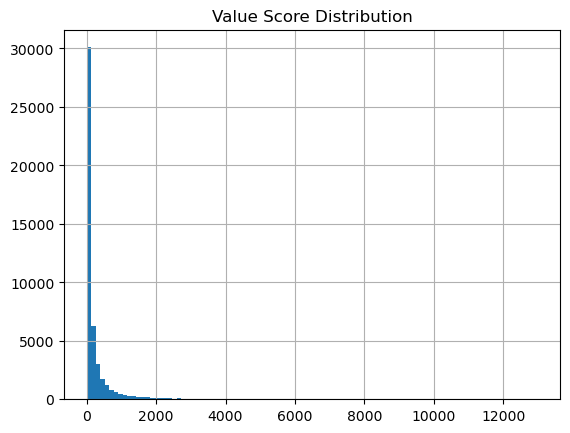

In [73]:
# 3. Plot quick distribution (important)

df_feat["value_score"].hist(bins=100)
plt.title("Value Score Distribution")
plt.show()

In [74]:
df_feat_clean = df_feat.dropna(subset=["price", "units_sold", "value_score"])

In [75]:
df_feat_clean["value_score"].describe()

count    47057.000000
mean       282.929893
std        712.427927
min          0.080652
25%         17.406440
50%         65.907729
75%        227.488152
max      12987.012987
Name: value_score, dtype: float64

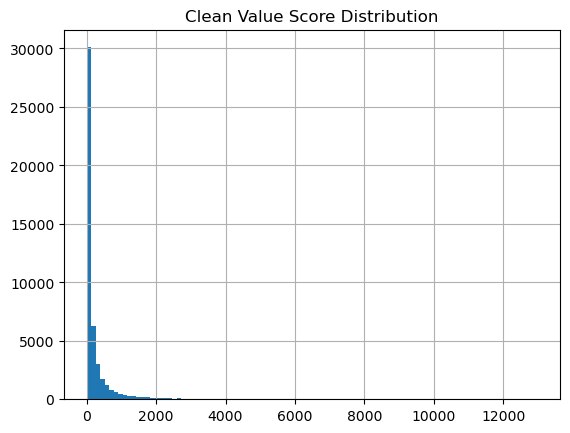

In [76]:
import matplotlib.pyplot as plt

df_feat_clean["value_score"].hist(bins=100)
plt.title("Clean Value Score Distribution")
plt.show()

In [77]:
df_feat["value_score"] = (
    df_feat["units_sold_log"] /
    (df_feat["price"] + 1)
)

In [79]:
df_feat["value_score"].describe()

count    47057.000000
mean         1.165743
std          0.860953
min          0.019185
25%          0.509976
50%          0.904926
75%          1.638127
max          6.506338
Name: value_score, dtype: float64

<Axes: >

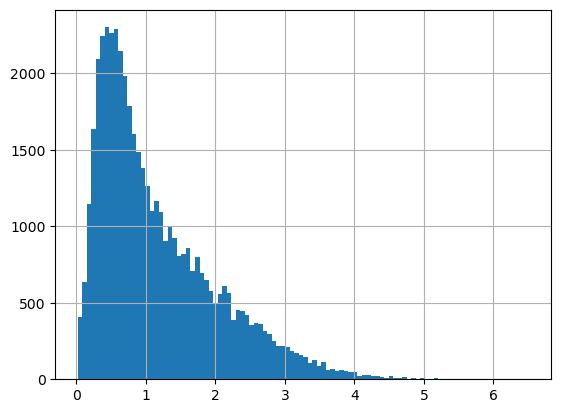

In [80]:
df_feat["value_score"].hist(bins=100)

In [81]:
df_feat[["price", "units_sold", "value_score"]].sort_values(
    "value_score", ascending=False
).head(10)

,price,units_sold,value_score
14565,0.22,2800.0,6.506338
73258,0.33,3900.0,6.217284
36432,0.29,3000.0,6.206745
18160,0.15,1200.0,6.166009
20046,0.18,1200.0,6.009246
36759,0.27,2000.0,5.985356
38333,0.27,1800.0,5.902439
13107,0.24,1500.0,5.898296
19464,0.18,1000.0,5.854877
30742,0.33,2100.0,5.752007


In [82]:
df.shape

(70292, 16)

In [83]:
df_feat.shape

(70292, 19)

In [84]:
df_feat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70292 entries, 0 to 82104
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   goods-title-link--jump        1 non-null      object  
 1   goods-title-link--jump href   1 non-null      object  
 2   rank-title                    12173 non-null  object  
 3   rank-sub                      12173 non-null  object  
 4   price                         70292 non-null  float64 
 5   discount                      46689 non-null  float64 
 6   selling_proposition           47057 non-null  object  
 7   goods-title-link              70291 non-null  object  
 8   source_file                   70292 non-null  object  
 9   color-count                   16571 non-null  float64 
 10  blackfridaybelts-bg src       3408 non-null   object  
 11  blackfridaybelts-content      3408 non-null   object  
 12  product-locatelabels-img src  2830 non-null   objec

In [85]:
df_feat.isna().sum().sort_values(ascending=False).head(10)

goods-title-link--jump          70291
goods-title-link--jump href     70291
product-locatelabels-img src    67462
blackfridaybelts-content        66884
blackfridaybelts-bg src         66884
rank-title                      58119
rank-sub                        58119
color-count                     53721
discount                        23603
selling_proposition             23235
dtype: int64

In [86]:
df_feat.duplicated().sum()

np.int64(0)

# 🧹 Data Cleaning Summary

## 📊 Dataset Overview
- Raw shape: (82105, 13)
- Final shape: (70292, 19)

## 🧽 Cleaning Steps Performed
- Removed duplicate rows
- Cleaned price column (removed currency symbols, converted to float)
- Handled extreme outliers in price using percentile-based filtering
- Extracted and cleaned units_sold from textual sales data
- Converted sales to numeric values (including k → thousands)
- Handled missing values in discount and selling_proposition

## 🔧 Feature Engineering
- Created log-transformed sales feature: units_sold_log
- Created value_score = units_sold_log / (price + 1)

## ⚠️ Notes
- value_score is a derived analytical metric, not a raw market value
- Extreme values were handled using robust statistical filtering (percentiles)

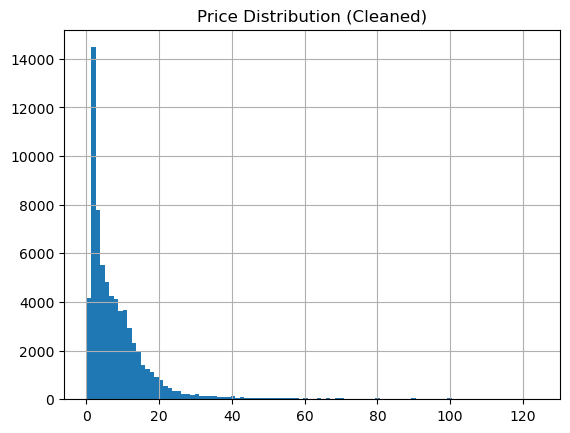

In [88]:
import matplotlib.pyplot as plt

df_feat["price"].hist(bins=100)
plt.title("Price Distribution (Cleaned)")
plt.show()

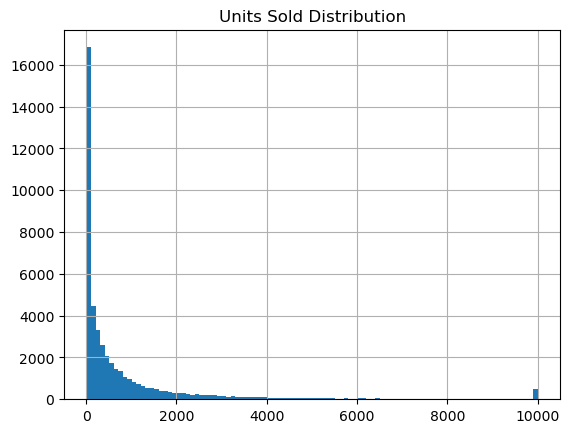

In [89]:
df_feat["units_sold"].hist(bins=100)
plt.title("Units Sold Distribution")
plt.show()

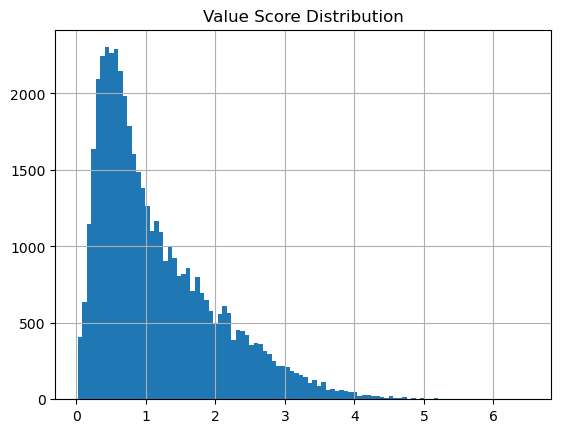

In [90]:
df_feat["value_score"].hist(bins=100)
plt.title("Value Score Distribution")
plt.show()

In [91]:
df_feat.isna().sum().sort_values(ascending=False).head(10)

goods-title-link--jump          70291
goods-title-link--jump href     70291
product-locatelabels-img src    67462
blackfridaybelts-content        66884
blackfridaybelts-bg src         66884
rank-title                      58119
rank-sub                        58119
color-count                     53721
discount                        23603
selling_proposition             23235
dtype: int64

In [92]:
df_feat.shape
df_feat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70292 entries, 0 to 82104
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   goods-title-link--jump        1 non-null      object  
 1   goods-title-link--jump href   1 non-null      object  
 2   rank-title                    12173 non-null  object  
 3   rank-sub                      12173 non-null  object  
 4   price                         70292 non-null  float64 
 5   discount                      46689 non-null  float64 
 6   selling_proposition           47057 non-null  object  
 7   goods-title-link              70291 non-null  object  
 8   source_file                   70292 non-null  object  
 9   color-count                   16571 non-null  float64 
 10  blackfridaybelts-bg src       3408 non-null   object  
 11  blackfridaybelts-content      3408 non-null   object  
 12  product-locatelabels-img src  2830 non-null   objec

In [93]:
cols_keep = [
    "price",
    "discount",
    "selling_proposition",
    "source_file",
    "color-count",
    "units_sold",
    "units_sold_log",
    "price_category",
    "has_discount",
    "value_score"
]

df_feat[cols_keep].to_csv("shein_cleaned_dataset_lite.csv", index=False)